# 06. Árvore de Decisão para Análise de Sentimentos

Este notebook apresenta a implementação e avaliação de um modelo de **Árvore de Decisão** para a classificação de sentimentos nas avaliações do IMDB.

## Etapas
1. Importação das bibliotecas e módulos.
2. Carregamento do conjunto de dados com embeddings pré-computados.
3. Separação de features e variável alvo.
4. Divisão dos dados em treino e teste (estratificada).
5. Treinamento da Árvore de Decisão e ajuste de hiperparâmetros.
6. Avaliação do modelo (métricas e Matriz de Confusão).
7. Exemplo prático de predição.

In [ ]:
import sys
import re
from html import unescape
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR / "src") not in sys.path:
    sys.path.append(str(ROOT_DIR / "src"))

def normalize_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [ ]:
DATA_PATH = ROOT_DIR / "IMDB_Dataset_menor.csv"
if not DATA_PATH.exists():
    DATA_PATH = ROOT_DIR / "data" / "raw" / "IMDB_Dataset_menor.csv"

df = pd.read_csv(DATA_PATH)
print(f"Dataset bruto carregado: {df.shape}")

# normaliza o texto
df["review_clean"] = df["review"].apply(normalize_text)
print("Normalização concluída com sucesso!")
df[["review", "review_clean", "sentiment"]].head(3)

Dataset bruto carregado: (2000, 2)
Normalização concluída com sucesso!


,review,review_clean,sentiment
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,a wonderful little production. the filming tec...,positive
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,positive


In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

print("Gerando embeddings das avaliações...")
X = model.encode(df["review_clean"].tolist(), show_progress_bar=True)
y = df["sentiment"].to_numpy()

print(f"\nSucesso! Matriz X gerada com formato: {X.shape}")
print(f"Vetor y gerado com formato: {y.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Gerando embeddings das avaliações...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]


Sucesso! Matriz X gerada com formato: (2000, 384)
Vetor y gerado com formato: (2000,)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

Treino: 1600 amostras | Teste: 400 amostras


In [ ]:
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

base_dt = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(base_dt, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_dt = grid_search.best_estimator_
print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")

Melhores parâmetros encontrados: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


In [26]:
y_pred = best_dt.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("--- Métricas de Desempenho ---")
print(f"Acurácia:  {acc:.4f}")
print(f"Precisão:  {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}\n")

print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))

--- Métricas de Desempenho ---
Acurácia:  0.6250
Precisão:  0.6251
Recall:    0.6250
F1-Score:  0.6250

--- Relatório de Classificação ---
              precision    recall  f1-score   support

    negative       0.62      0.63      0.63       199
    positive       0.63      0.62      0.62       201

    accuracy                           0.62       400
   macro avg       0.63      0.63      0.62       400
weighted avg       0.63      0.62      0.62       400



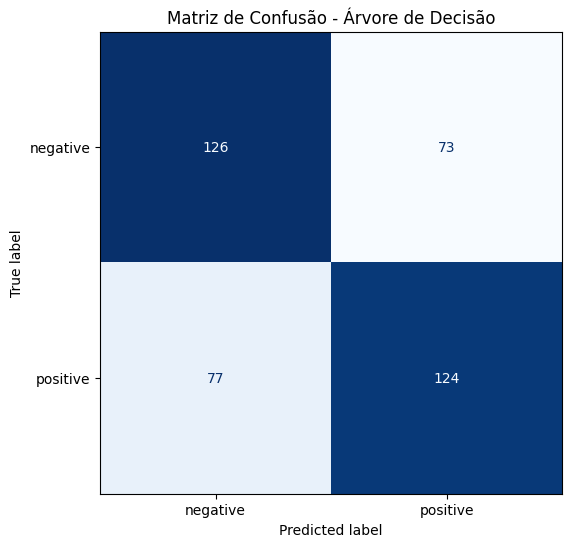

In [27]:
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de Confusão - Árvore de Decisão")
plt.show()

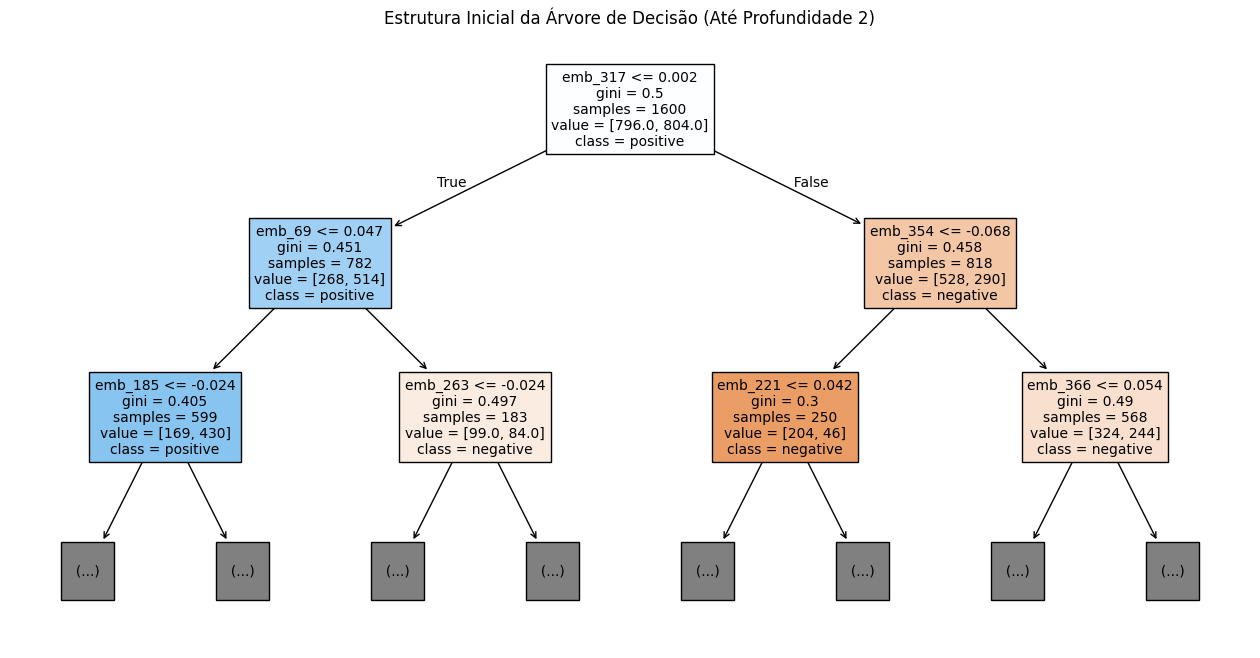

In [ ]:
# gera a lista com os nomes das 384 features de embedding
feature_cols = [f"emb_{i}" for i in range(X.shape[1])]

# árvore de decisão
plt.figure(figsize=(16, 8))
plot_tree(
    best_dt, 
    max_depth=2, 
    feature_names=feature_cols, 
    class_names=[str(c) for c in np.unique(y)], 
    filled=True, 
    fontsize=10
)
plt.title("Estrutura Inicial da Árvore de Decisão (Até Profundidade 2)")
plt.show()

## Conclusão

- A Árvore de Decisão foi treinada e otimizada via `GridSearchCV`.
- Os hiperparâmetros como `max_depth` e `min_samples_split` garantiram o controle do overfit.
- As métricas calculadas serão consolidadas no notebook comparativo posterior (`07_comparacao_modelos.ipynb`).